In [3]:
!pip install statsmodels tqdm

In [7]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm 

warnings.filterwarnings("ignore")

# 1: load chronologically partitioned and scaled data for Agus II to ensure fair benchmarking against the LSTM 
data_dir = 'Model_Ready_Data_Agus2'
df_train = pd.read_csv(f'{data_dir}/Train.csv', index_col='Time', parse_dates=True, dayfirst=False)
df_test = pd.read_csv(f'{data_dir}/Test.csv', index_col='Time', parse_dates=True, dayfirst=False)

target_col = 'Total_Power'
target_idx = df_train.columns.get_loc(target_col)

y_train_scaled = df_train[target_col].values
y_test_scaled = df_test[target_col].values
test_dates = df_test.index

# 2: fit the ARIMA(2, 1, 2) statistical baseline model and extract residuals
model = ARIMA(y_train_scaled, order=(2, 1, 2))
fitted_model = model.fit()
residuals = fitted_model.resid

# 3: generate rolling 1-step ahead point predictions on the test set
res_test = fitted_model.apply(y_test_scaled, refit=False)
point_preds_scaled = res_test.fittedvalues

# 4: execute non-parametric bootstrapping simulation to construct 90% confidence intervals
n_iterations = 1000
alpha = 0.10
simulated_paths = np.zeros((len(y_test_scaled), n_iterations))

for i in tqdm(range(n_iterations), desc="Bootstrapping"):
    sampled_errors = np.random.choice(residuals, size=len(y_test_scaled), replace=True)
    simulated_paths[:, i] = point_preds_scaled + sampled_errors

lower_bounds_scaled = np.percentile(simulated_paths, (alpha / 2) * 100, axis=1)
upper_bounds_scaled = np.percentile(simulated_paths, (1 - alpha / 2) * 100, axis=1)

# 5: reconstruct the robust scaler and inverse transform the predictions back to the real MW
original_df = pd.read_csv('Processed_Agus2_Dataset.csv', index_col='Time', parse_dates=True, dayfirst=False)
features = original_df.columns.tolist()
train_end = int(len(original_df) * 0.60)

scaler = RobustScaler()
scaler.fit(original_df.iloc[:train_end][features])

def unscale_array(scaled_array):
    dummy = np.zeros((len(scaled_array), len(features)))
    dummy[:, target_idx] = scaled_array
    return scaler.inverse_transform(dummy)[:, target_idx]

actual_mw = unscale_array(y_test_scaled)
point_preds_mw = unscale_array(point_preds_scaled)
lower_bounds_mw = unscale_array(lower_bounds_scaled)
upper_bounds_mw = unscale_array(upper_bounds_scaled)

# 6: enforce physical operational constriants specific to Agus II and export baseline results
MAX_CAPACITY = 180.0
RIPARIAN_MIN = 0.85

arima_df = pd.DataFrame({
    'Time': test_dates,
    'Actual_MW': actual_mw,
    'Point_Prediction_MW': point_preds_mw,
    'Physics_Lower_MW': lower_bounds_mw,
    'Physics_Upper_MW': upper_bounds_mw
})

arima_df['Physics_Lower_MW'] = arima_df['Physics_Lower_MW'].clip(lower=RIPARIAN_MIN)
arima_df['Physics_Upper_MW'] = arima_df['Physics_Upper_MW'].clip(upper=MAX_CAPACITY)
arima_df['Point_Prediction_MW'] = arima_df['Point_Prediction_MW'].clip(lower=RIPARIAN_MIN, upper=MAX_CAPACITY)

file_name = 'Agus2_ARIMA_Baseline_Results.csv'
arima_df.to_csv(file_name, index=False)

Starting Honest ARIMA Modeling with Un-Scaling (Agus 2)...

Fitting ARIMA(2,1,2)...
Generating rolling 1-step ahead point predictions...
Running Bootstrapping Simulation for 90% Confidence Intervals...


Bootstrapping: 100%|█████████████████| 1000/1000 [00:00<00:00, 3037.52it/s]



Un-scaling ARIMA predictions back to real-world MW...
Applying Physical Constraints...
SUCCESS! Unscaled ARIMA results safely saved to 'Agus2_ARIMA_Baseline_Results.csv'.


Generating Visualizations for ARIMA Baseline (Agus 2)...


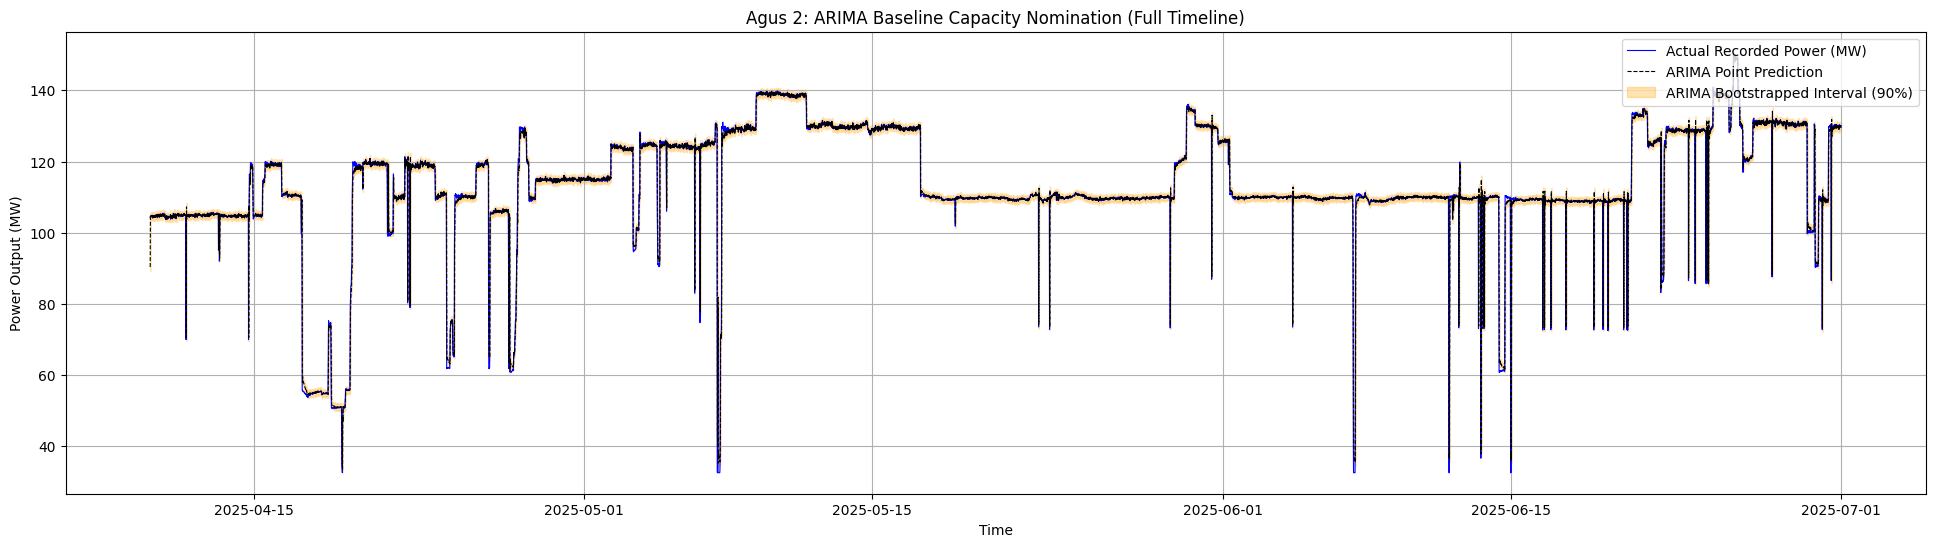

Generating zoomed-in 200-step visualization...


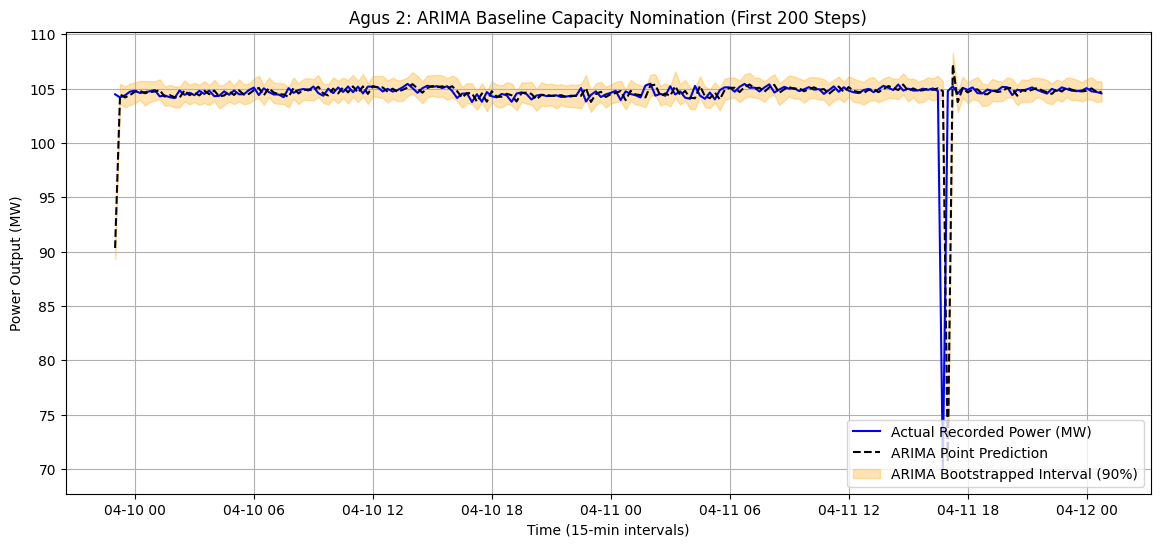

SUCCESS! Both ARIMA plots have been saved.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1: load the exported ARIMA baseline results for the Agus II
df_arima = pd.read_csv('Agus2_ARIMA_Baseline_Results.csv', index_col='Time', parse_dates=True)

# 2: visualize the full timeline of the actual power generation against ARIMA predictions and bootstrapped bounds
plt.figure(figsize=(24, 6))

plt.plot(df_arima.index, df_arima['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=0.8)
plt.plot(df_arima.index, df_arima['Point_Prediction_MW'], label='ARIMA Point Prediction', color='black', linestyle='dashed', linewidth=0.8)

plt.fill_between(df_arima.index, 
                 df_arima['Physics_Lower_MW'], 
                 df_arima['Physics_Upper_MW'], 
                 color='orange', alpha=0.3, label='ARIMA Bootstrapped Interval (90%)')

plt.title('Agus 2: ARIMA Baseline Capacity Nomination (Full Timeline)')
plt.xlabel('Time')
plt.ylabel('Power Output (MW)')
plt.legend(loc='upper right')
plt.grid(True)

# 3: export macro view figure for comparative analysis against LSTM-CQR model
plt.savefig('Agus2_ARIMA_Intervals_Whole.png', dpi=400, bbox_inches='tight')
plt.show()

# 3.1: zoomed visualization
plt.figure(figsize=(14, 6))
subset_arima = df_arima.iloc[:200]

plt.plot(subset_arima.index, subset_arima['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=1.5)
plt.plot(subset_arima.index, subset_arima['Point_Prediction_MW'], label='ARIMA Point Prediction', color='black', linestyle='dashed', linewidth=1.5)

plt.fill_between(subset_arima.index, 
                 subset_arima['Physics_Lower_MW'], 
                 subset_arima['Physics_Upper_MW'], 
                 color='orange', alpha=0.3, label='ARIMA Bootstrapped Interval (90%)')

plt.title('Agus 2: ARIMA Baseline Capacity Nomination (First 200 Steps)')
plt.xlabel('Time (15-min intervals)')
plt.ylabel('Power Output (MW)')
plt.legend(loc='lower right')
plt.grid(True)

plt.savefig('Agus2_ARIMA_Intervals_Zoomed.png', dpi=300, bbox_inches='tight')
plt.show()